# Notebook 04: Positional Entropy Vectors and Boundary Gradient Discovery

## 1.1 Positional Shannon Entropy
To find where fields transition without a blueprint, we calculate the Shannon Entropy $H(M)$ for each vertical column offset index $j$ across our tensor matrix. This metric evaluates the statistical uncertainty and variability at each position:

$$H(M_j) = - \sum_{v \in V_j} P(v) \log_2 P(v)$$

Where:
* $V_j$ represents the unique set of byte configurations observed within vertical column slice $j$.
* $P(v)$ represents the empirical probability of a specific byte value occurring at that offset.

## 1.2 Boundary Gradient Identification
A structural field boundary is likely to occur where the local entropy values shift rapidly between adjacent columns. We highlight these boundary points by taking the absolute first-order difference between positions:

$$\Delta H(M_j) = |H(M_{j+1}) - H(M_j)|$$

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# Load the real-world vectorized matrix cached from Notebook 01
PROCESSED_MATRIX_PATH = os.path.join("..", "data", "processed", "vectorized_matrix.npy")
X = np.load(PROCESSED_MATRIX_PATH)

print(f"Matrix loaded for Entropy Extraction. Shape: {X.shape[0]} Packets x {X.shape[1]} Columns")

Matrix loaded for Entropy Extraction. Shape: 1275 Packets x 42 Columns


## 2.1 Calculating Column-Wise Entropy Signatures
We calculate the uncertainty score for each of our 42 tracking columns to isolate stable zones from dynamic fields.

In [3]:
def calculate_positional_entropy(matrix: np.ndarray) -> np.ndarray:
    N, M = matrix.shape
    entropy_vector = np.zeros(M)
    
    for j in range(M):
        column_values = matrix[:, j]
        # Extract individual value occurrences
        _, counts = np.unique(column_values, return_counts=True)
        probabilities = counts / N
        
        # Calculate Shannon Entropy for the column slice
        entropy_vector[j] = -np.sum(probabilities * np.log2(probabilities + 1e-12))
        
    return entropy_vector

# Execute calculations
entropy_profile = calculate_positional_entropy(X)

# Map differences to identify boundary transitions
delta_entropy = np.abs(np.diff(entropy_profile, prepend=0))

# Display structural breakdown
entropy_summary = pd.DataFrame({
    "Shannon Entropy H(M)": entropy_profile,
    "Delta Gradient Matrix": delta_entropy
}, index=[f"Byte Offset {i}" for i in range(X.shape[1])])

entropy_summary.head(12)

,Shannon Entropy H(M),Delta Gradient Matrix
Byte Offset 0,-1.442823e-12,1.442823e-12
Byte Offset 1,-1.442823e-12,0.000000e+00
Byte Offset 2,-1.442823e-12,0.000000e+00
Byte Offset 3,-1.442823e-12,0.000000e+00
Byte Offset 4,-1.442823e-12,0.000000e+00
Byte Offset 5,-1.442823e-12,0.000000e+00
Byte Offset 6,-1.442823e-12,0.000000e+00
Byte Offset 7,9.797735e-01,9.797735e-01
Byte Offset 8,-1.442823e-12,9.797735e-01
Byte Offset 9,1.560632e-01,1.560632e-01


## 3.1 Plotting the Entropy Segmentation Gradients

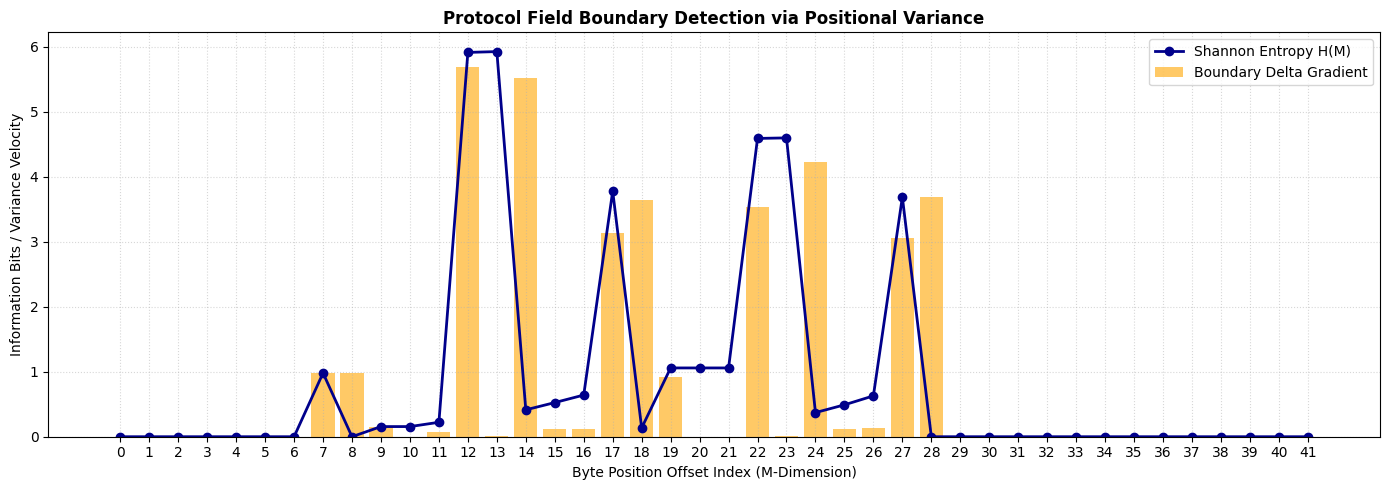

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(range(len(entropy_profile)), entropy_profile, marker='o', color='darkblue', linewidth=2, label="Shannon Entropy H(M)")
plt.bar(range(len(delta_entropy)), delta_entropy, color='orange', alpha=0.6, label="Boundary Delta Gradient")

plt.title("Protocol Field Boundary Detection via Positional Variance", fontsize=12, fontweight='bold')
plt.xlabel("Byte Position Offset Index (M-Dimension)", fontsize=10)
plt.ylabel("Information Bits / Variance Velocity", fontsize=10)
plt.xticks(range(0, X.shape[1]))
plt.grid(axis='both', linestyle=':', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np

# Ensure the processed artifacts directory exists
processed_dir = os.path.join("..", "data", "processed")
os.makedirs(processed_dir, exist_ok=True)

entropy_cache_path = os.path.join(processed_dir, "entropy_profile.npy")

# Serialize the raw Shannon entropy vector as an optimized NumPy binary file
np.save(entropy_cache_path, entropy_profile)
print(f"Success! Entropy profile cached for downstream pipeline stages at:\n{entropy_cache_path}")

Success! Entropy profile cached for downstream pipeline stages at:
..\data\processed\entropy_profile.npy


: 